In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load WRDS CSV
df = pd.read_csv("kxhzuzwygkynusep.csv")

# Keep only needed columns
df = df[["date", "PRC"]]

# Rename columns
df = df.rename(columns={"PRC": "spot"})

# Convert price to absolute value (CRSP sometimes stores negative prices)
df["spot"] = df["spot"].abs()

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date
df = df.sort_values("date")

# Remove duplicate rows
df = df.drop_duplicates()

# Drop missing values
df = df.dropna()

# Ensure price > 0
df = df[df["spot"] > 0]

# Reset index
df = df.reset_index(drop=True)

# Final check
print("Number of rows:", len(df))
print("Missing values:", df.isnull().sum())

# Save cleaned dataset
df.to_csv("clean_spy_data.csv", index=False)

print("Clean dataset saved to data/spy_clean.csv")

Number of rows: 13900
Missing values: date    0
spot    0
dtype: int64
Clean dataset saved to data/spy_clean.csv


Episodes shape: (13880, 21)


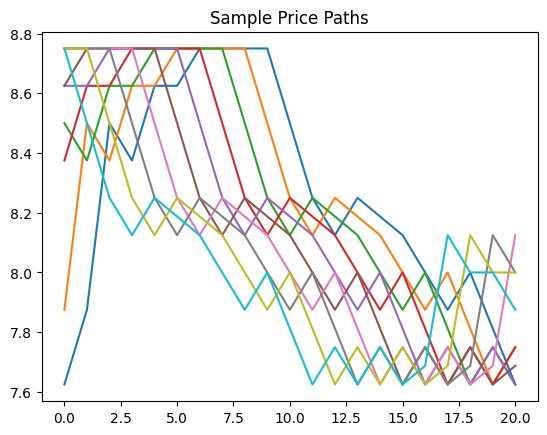

In [19]:

spot = pd.read_csv("clean_spy_data.csv")

prices = spot["spot"].values

n_steps = 20   # length of hedging horizon

episodes = []

for i in range(len(prices) - n_steps):
    window = prices[i:i+n_steps+1]
    episodes.append(window)

episodes = np.array(episodes)

print("Episodes shape:", episodes.shape)

for i in range(10):
    plt.plot(episodes[i])

plt.title("Sample Price Paths")
plt.show()

OPTIONS DATA

In [20]:
opt = pd.read_csv("scjjthfjjyerjapz.csv")
print(opt.columns)

opt = opt[opt["cp_flag"] == "C"]
opt["call_price"] = (opt["best_bid"] + opt["best_offer"]) / 2 #compute option price

#now we can rename and keep the important columns:
opt = opt.rename(columns={
    "impl_volatility": "ivol",
    "delta": "call_delta",
    "vega": "call_vega"
})
opt = opt[[
    "date",
    "exdate",
    "strike_price",
    "call_price",
    "call_delta",
    "call_vega",
    "ivol"
]]

# remove unwanted rows
opt = opt.dropna()
opt = opt[opt["call_price"] > 0]
opt = opt[opt["ivol"] > 0]

# convert dates
opt["date"] = pd.to_datetime(opt["date"])
opt["exdate"] = pd.to_datetime(opt["exdate"])

# get time to maturity and set the window from 20 to 40 days
opt["ttm_days"] = (opt["exdate"] - opt["date"]).dt.days
opt = opt[(opt["ttm_days"] > 20) & (opt["ttm_days"] < 40)]

Index(['secid', 'date', 'exdate', 'cp_flag', 'strike_price', 'best_bid',
       'best_offer', 'impl_volatility', 'delta', 'vega', 'optionid',
       'index_flag', 'issuer', 'exercise_style'],
      dtype='object')


Merge datasets and select ATM option

In [21]:
# Load cleaned spot prices
spot["date"] = pd.to_datetime(spot["date"])

# Merge spot and options
merged_dataset = opt.merge(spot, on="date", how="inner")

# Find ATM option
merged_dataset["atm_dist"] = abs(merged_dataset["strike_price"] - merged_dataset["spot"])

# Sort so closest strike comes first
merged_dataset = merged_dataset.sort_values(["date", "atm_dist"])

# Keep the closest strike each day
merged_dataset = merged_dataset.groupby("date").first().reset_index()


# Final columns needed for model
merged_dataset = merged_dataset[[
    "date",
    "spot",
    "call_price",
    "call_delta",
    "call_vega",
    "ivol"
]]


# Remove any remaining bad rows

merged_dataset = merged_dataset.dropna()

merged_dataset = merged_dataset[merged_dataset["spot"] > 0]
merged_dataset = merged_dataset[merged_dataset["call_price"] > 0]


# Sort by date

merged_dataset = merged_dataset.sort_values("date")


# Save final dataset

merged_dataset.to_csv("spy_option_features.csv", index=False)

print("Final dataset created")
print(merged_dataset)

Final dataset created
           date       spot  call_price  call_delta  call_vega      ivol
0    2005-01-11  118.18000      30.450    0.995067   0.553873  0.361324
1    2005-01-12  118.57000      22.850    0.994953   0.559777  0.262101
2    2005-01-13  117.62000      29.900    0.989980   1.003162  0.406773
3    2005-01-14  118.24000      30.450    0.995620   0.454942  0.367156
4    2005-01-18  119.47000      25.650    0.996305   0.359921  0.306371
...         ...        ...         ...         ...        ...       ...
4500 2024-12-24  601.29999     407.245    0.996567   1.593602  1.779157
4501 2024-12-26  601.34003     422.140    0.997259   1.250103  1.940777
4502 2024-12-27  595.01001     256.520    0.998055   1.014085  0.644557
4503 2024-12-30  588.21997     250.585    0.985229   6.513665  0.914503
4504 2024-12-31  586.08002     148.745    0.980587   8.793222  0.451772

[4505 rows x 6 columns]


In [23]:
print(len(merged_dataset))

4505
